# Generate test images

In [1]:
from pathlib import Path
from inference import run_inference

run_inference(
    ldr_dir          = Path("nn_data/selected/LDR"),
    under_model_path = Path("models/model_under.pth"),
    over_model_path  = Path("models/model_over.pth"),
    out_dir          = Path("nn_data/results"),
    test_only        = True,  
)

Device: cpu

Loaded model_under.pth  (epoch 10, PSNR 27.13dB)
Loaded model_over.pth  (epoch 9, PSNR 24.38dB)
test_only=True — processing 7 test scenes (C40-C46)

  C40_LDR.tif
  C41_LDR.tif
  C42_LDR.tif
  C43_LDR.tif
  C44_LDR.tif
  C45_LDR.tif
  C46_LDR.tif

Done. Results saved to nn_data\results


# Visualize

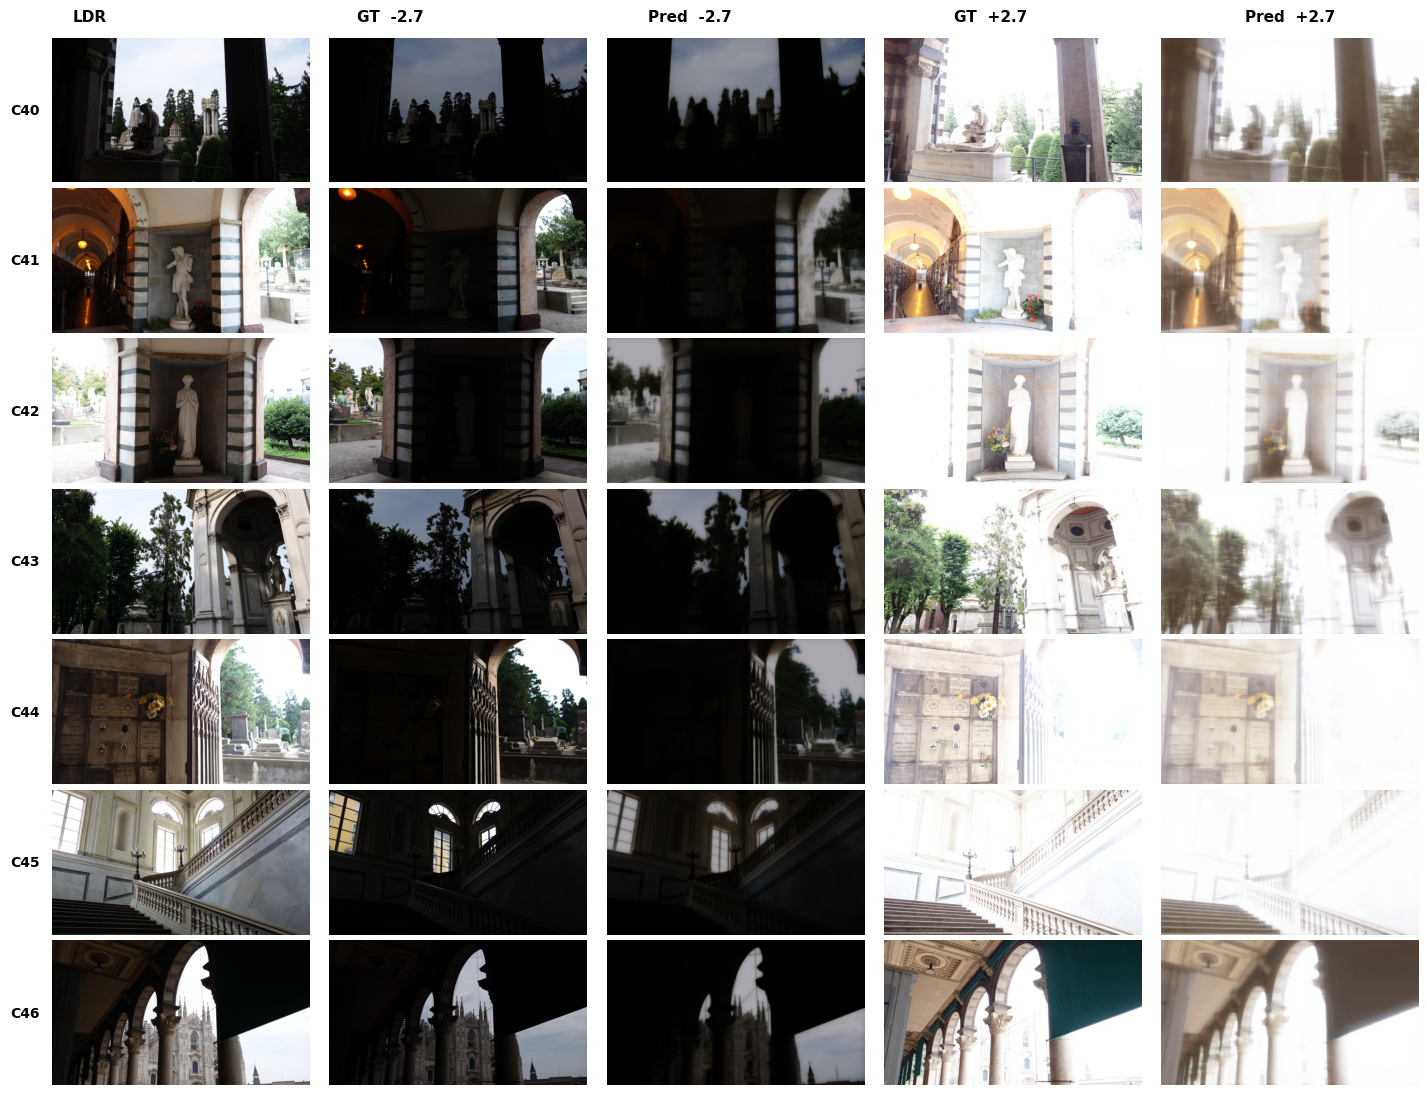

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from evaluate import index_dir, load_rgb_uint8, TEST_SCENES

LDR_DIR        = Path("nn_data/selected/LDR")
GT_UNDER_DIR   = Path("nn_data/selected/Bracketed_images-27")
GT_OVER_DIR    = Path("nn_data/selected/Bracketed_images+27")
PRED_UNDER_DIR = Path("nn_data/results/under")
PRED_OVER_DIR  = Path("nn_data/results/over")

ldr_map        = index_dir(LDR_DIR)
gt_under_map   = index_dir(GT_UNDER_DIR)
gt_over_map    = index_dir(GT_OVER_DIR)
pred_under_map = index_dir(PRED_UNDER_DIR)
pred_over_map  = index_dir(PRED_OVER_DIR)

scenes = sorted(
    set(ldr_map) & set(gt_under_map) & set(gt_over_map)
    & set(pred_under_map) & set(pred_over_map) & TEST_SCENES
)

cols      = ["LDR", "GT  -2.7", "Pred  -2.7", "GT  +2.7", "Pred  +2.7"]
N         = len(scenes)
img_aspect = 1080 / 1920
col_w_in   = 3.0
row_h_in   = col_w_in * img_aspect
header_h   = 0.35  

fig, axes = plt.subplots(
    N, 5,
    figsize=(col_w_in * 5, row_h_in * N + header_h),
    gridspec_kw={"top": 1 - header_h / (row_h_in * N + header_h)}
)

for col_idx, title in enumerate(cols):
    x = (col_idx + 0.5) / 5
    fig.text(x, 1.0 - (header_h * 0.4) / (row_h_in * N + header_h),
             title, ha="center", va="center",
             fontsize=11, fontweight="bold")

for row, scene in enumerate(scenes):
    imgs = [
        load_rgb_uint8(ldr_map[scene]),
        load_rgb_uint8(gt_under_map[scene]),
        load_rgb_uint8(pred_under_map[scene]),
        load_rgb_uint8(gt_over_map[scene]),
        load_rgb_uint8(pred_over_map[scene]),
    ]
    h_ref, w_ref = imgs[2].shape[:2]
    imgs = [cv2.resize(img, (w_ref, h_ref), interpolation=cv2.INTER_AREA) for img in imgs]

    for col, img in enumerate(imgs):
        ax = axes[row, col]
        ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.text(-0.05, 0.5, scene,
                    transform=ax.transAxes,
                    fontsize=10, fontweight="bold",
                    va="center", ha="right")

plt.subplots_adjust(left=0.07, right=0.99, wspace=0.02, hspace=0.04)
plt.show()

In [4]:
from evaluate import evaluate

results = evaluate(
    gt_under_dir   = Path("nn_data/selected/Bracketed_images-27"),
    gt_over_dir    = Path("nn_data/selected/Bracketed_images+27"),
    pred_under_dir = Path("nn_data/results/under"),
    pred_over_dir  = Path("nn_data/results/over"),
)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\flang\miniforge3\envs\pro1_sigk\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\flang\miniforge3\envs\pro1_sigk\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\flang/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:41<00:00, 5.84MB/s] 


Loading model from: c:\Users\flang\miniforge3\envs\pro1_sigk\Lib\site-packages\lpips\weights\v0.1\alex.pth
  C40  PSNR under=24.13dB  over=15.56dB  LPIPS under=0.2507  over=0.7265
  C41  PSNR under=16.83dB  over=18.39dB  LPIPS under=0.4322  over=0.5169
  C42  PSNR under=17.64dB  over=22.28dB  LPIPS under=0.4085  over=0.4356
  C43  PSNR under=18.72dB  over=15.50dB  LPIPS under=0.5319  over=0.7178
  C44  PSNR under=17.18dB  over=24.36dB  LPIPS under=0.3274  over=0.4569
  C45  PSNR under=21.47dB  over=20.07dB  LPIPS under=0.3316  over=0.4411
  C46  PSNR under=21.65dB  over=16.81dB  LPIPS under=0.3280  over=0.6310

Metric                     PSNR      LPIPS
------------------------------------------------------------
underexposed              19.66     0.3729
overexposed               19.00     0.5608

